Converged in  : 2 iterations
Centroid shape: (4, 2)


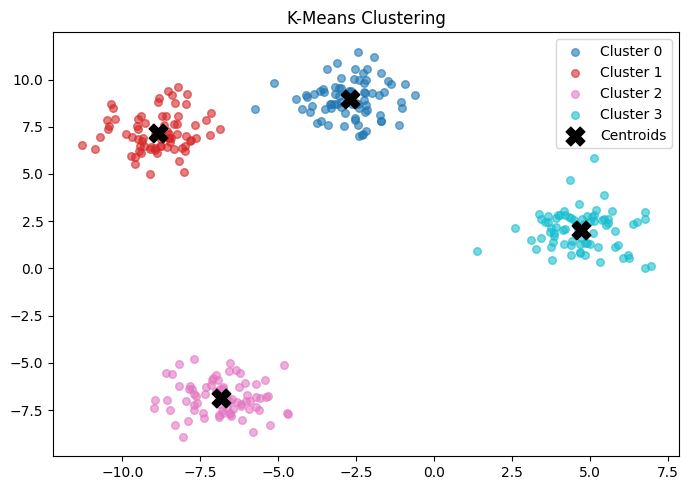


New point clusters: [3 3 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    """
    K-Means Clustering from scratch.

    Parameters
    ----------
    k : int
        Number of clusters.
    max_iters : int
        Maximum number of iterations.
    tol : float
        Convergence tolerance (min centroid shift to continue).
    random_state : int | None
        Seed for reproducibility.
    """


    def __init__(self, k=3, max_iters=300, tol=1e-4, random_state=None):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.n_iter_ = 0    # iterations until convergence



    def _init_random(self, X):
        """Pick k random data points as initial centroids."""
        rng = np.random.default_rng(self.random_state)
        indices = rng.choice(len(X), size=self.k, replace=False)
        return X[indices].copy()


    def _assign_labels(self, X):
        """Assign each sample to its nearest centroid (vectorized)."""
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)



    def _update_centroids(self, X, labels):
     new_centroids = np.zeros_like(self.centroids)
     for c in range(self.k):
      members = X[labels == c]
      if len(members) == 0:
        new_centroids[c] = self.centroids[c]  # keep it where it was
      else:
        new_centroids[c] = members.mean(axis=0)
     return new_centroids



    def fit(self, X):
        """
        Fit K-Means to data X.
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
        """
        X = np.asarray(X, dtype=float)
        self.centroids = self._init_random(X)
        converged = False
        for i in range(self.max_iters):
          labels = self._assign_labels(X)
          new_centroids = self._update_centroids(X, labels)
          shift = np.linalg.norm(new_centroids - self.centroids)
          self.centroids = new_centroids
          if shift < self.tol:
            converged = True
            break
        if converged:
          self.n_iter_ = i + 1
        else:
          self.n_iter_ = self.max_iters
        self.labels_ = self._assign_labels(X)
        return self



    def predict(self, X):
        """Assign new points to the nearest centroid."""
        X = np.asarray(X, dtype=float)
        return self._assign_labels(X)



def plot_clusters(X, labels, centroids, title="K-Means Clustering"):
    """Scatter plot colored by cluster (2-D data only)."""
    k = len(centroids)

    colors = plt.colormaps["tab10"].resampled(k)

    plt.figure(figsize=(7, 5))
    for c in range(k):
        mask = labels == c
        plt.scatter(X[mask, 0], X[mask, 1],
                    color=colors(c), alpha=0.6, s=30, label=f"Cluster {c}")
    plt.scatter(centroids[:, 0], centroids[:, 1],
                color="black", marker="X", s=180, zorder=5, label="Centroids")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("clusters.png", dpi=150)
    plt.show()


if __name__ == "__main__":
    from sklearn.datasets import make_blobs

    # ── 1. Generate synthetic data ──────────────────────────────────
    X, y_true = make_blobs(n_samples=300, centers=4,
                            random_state=42)

    # ── 3. Fit with optimal k ────────────────────────────────────────
    km = KMeans(k=4, random_state=42)
    km.fit(X)

    print(f"Converged in  : {km.n_iter_} iterations")
    print(f"Centroid shape: {km.centroids.shape}")

    plot_clusters(X, km.labels_, km.centroids)

    # ── 4. Predict on new points ─────────────────────────────────────
    new_points = np.array([[0, 0], [5, 5], [-3, 2]])
    print(f"\nNew point clusters: {km.predict(new_points)}")